# ML Intrusion Detection System

Trained an XGBoost model on the CICIDS 2017 dataset to classify network traffic as either benign or an attack.
The dataset has real network flows captured over a full week, covering 27 different attack types.

Basic idea: every network connection has measurable stats (packet sizes, timing, TCP flags etc).
Attacks produce different patterns to normal traffic, so a model can learn to tell them apart.

**Steps:**
1. Load all the CSVs and merge them
2. Drop useless columns and clean up bad values
3. Turn labels into binary (BENIGN = 0, ATTACK = 1)
4. Train/test split
5. Train XGBoost
6. Check the results and save

## 1. Imports

In [1]:
import pandas as pd       # dataframes
import numpy as np        # numbers/arrays
import os                 # file system stuff
import warnings
warnings.filterwarnings('ignore')  # stops annoying warnings cluttering the output

## 2. Load the Dataset

The data comes split across multiple CSVs, one per day of the week.
Loop through them all, load each one, then stack them into one big DataFrame.

In [2]:
data_path = '../data'
dfs = []

for file in os.listdir(data_path):
    if file.endswith('.csv'):
        print(f'Loading {file}...')
        # low_memory=False stops pandas complaining about mixed types mid-read
        df = pd.read_csv(os.path.join(data_path, file), encoding='utf-8', low_memory=False)
        dfs.append(df)

# stack all the daily dataframes into one
# ignore_index resets the row numbers so they go 0, 1, 2... instead of repeating
data = pd.concat(dfs, ignore_index=True)
print(f'\nTotal rows: {len(data):,}')
print(f'Total columns: {len(data.columns)}')

Loading friday.csv...
Loading friday_plus.csv...
Loading monday.csv...
Loading monday_plus.csv...
Loading thursday.csv...
Loading thursday_plus.csv...
Loading tuesday.csv...
Loading tuesday_plus.csv...
Loading wednesday.csv...
Loading wednesday_plus.csv...

Total rows: 4,199,942
Total columns: 105


## 3. Quick Look at the Data

Just checking what we've got before touching anything.

In [31]:
print(data.shape)              # rows x columns
print(data.columns.tolist())   # all the column names
print(data.dtypes)             # what type each column is (int, float, string etc)

(4199942, 105)
['Src IP dec', 'Src Port', 'Dst IP dec', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd RST Flags', 'Bwd RST Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Fl

## 4. Check the Labels

See what attack types are in the dataset and how many of each there are.
Worth knowing if the classes are heavily imbalanced (they are — most traffic is benign).

In [32]:
print(data['Label'].value_counts())

Label
BENIGN                                    3165122
Portscan                                   318132
DoS Hulk                                   316936
DDoS                                       190288
Infiltration - Portscan                    143534
DoS GoldenEye                               15134
Botnet - Attempted                           8134
FTP-Patator                                  7944
DoS Slowloris                                7718
DoS Slowhttptest - Attempted                 6736
SSH-Patator                                  5922
DoS Slowloris - Attempted                    3694
DoS Slowhttptest                             3480
Web Attack - Brute Force - Attempted         2584
Botnet                                       1472
Web Attack - XSS - Attempted                 1310
DoS Hulk - Attempted                         1162
DoS GoldenEye - Attempted                     160
Web Attack - Brute Force                      146
Infiltration - Attempted                    

## 5. Clean the Data

Drop the columns that aren't useful for training:
- IP addresses and Flow ID are just identifiers, not actual signal
- Timestamps don't help the model generalise
- The Local_* columns are just metadata padding

Also need to handle infinite values — these appear in rate calculations when flow duration is 0.
XGBoost can't deal with them so we swap them out for NaN then drop those rows.

In [33]:
# grab all column names containing 'Local' using a list comprehension
drop_cols = ['Src IP dec', 'Dst IP dec', 'Timestamp', 'Flow ID', 
             'Attempted Category'] + [c for c in data.columns if 'Local' in c]

# errors='ignore' so it doesn't break if a column isn't there for some reason
data = data.drop(columns=drop_cols, errors='ignore')

# swap inf/-inf for NaN then drop any row that has a NaN
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

print(f'Rows after cleaning: {len(data):,}')
print(f'Columns remaining: {len(data.columns)}')

Rows after cleaning: 4,199,942
Columns remaining: 85


## 6. Create the Target Variable

We want binary classification: is this flow an attack or not?

Create a `target` column where:
- 0 = BENIGN
- 1 = anything else (any attack type)

In [34]:
# the comparison gives True/False, astype(int) converts that to 1/0
data['target'] = (data['Label'] != 'BENIGN').astype(int)

print(data['target'].value_counts())
print(f"\nAttack rate: {data['target'].mean()*100:.1f}%")

target
0    3165122
1    1034820
Name: count, dtype: int64

Attack rate: 24.6%


## 7. Train/Test Split

Split 80% for training, 20% held back for testing.
The test set is data the model never sees — used to check it actually generalises rather than just memorising the training data.

`stratify=y` keeps the same attack/benign ratio in both splits, which matters when classes are imbalanced.

In [35]:
from sklearn.model_selection import train_test_split

# X = all the features, y = what we're trying to predict
X = data.drop(columns=['Label', 'target'])
y = data['target']

# random_state=42 just makes the split the same every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} rows')
print(f'Test:  {len(X_test):,} rows')

Train: 3,359,953 rows
Test:  839,989 rows


## 8. Train the Model

Using XGBoost — basically a load of decision trees built one after another, where each tree tries to fix the mistakes of the previous ones. Works really well on tabular data.

Parameters worth knowing:
- `n_estimators` = how many trees to build
- `max_depth` = how deep each tree goes (too deep = overfitting)
- `learning_rate` = how aggressively each tree corrects the last (lower = more cautious)
- `subsample` and `colsample_bytree` = each tree only uses a random 80% of data/features, helps prevent overfitting
- `n_jobs=-1` = use all CPU cores, otherwise it takes ages

In [36]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

print('Training...')
model.fit(X_train, y_train)
print('Done.')

Training...
Done.


## 9. Evaluate

Accuracy alone is a bad metric here because 75% of data is benign — a model that just guesses BENIGN every time would get 75% accuracy but be completely useless.

Better metrics:
- **F1** — balance of precision and recall, better for imbalanced data
- **Precision** — of everything we flagged as an attack, how many were actually attacks?
- **Recall** — of all the actual attacks, how many did we catch?
- **Log Loss** — measures how confident the predictions are, not just if they're right or wrong

`predict_proba` gives a probability (e.g. 94% likely to be an attack) rather than just 0 or 1.
The `[:,1]` grabs the probability for the positive class (attack).

In [37]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, log_loss

y_pred = model.predict(X_test)            # hard predictions: 0 or 1
y_prob = model.predict_proba(X_test)[:,1] # probability of being an attack

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'Log Loss:  {log_loss(y_test, y_prob):.4f}')

Accuracy:  0.9999
F1 Score:  0.9998
Precision: 0.9998
Recall:    0.9998
Log Loss:  0.0005


## 10. Save the Model

Save the trained model so the Streamlit app can load it without having to retrain from scratch every time.

In [38]:
import joblib

# saves the model object to a .pkl file (basically serialises it)
joblib.dump(model, '../model/xgboost_ids.pkl')
print('Model saved.')

Model saved.


## 11. Feature Importance

XGBoost can tell us which features it actually used the most.
Good for sanity checking — if one feature is doing basically all the work it might mean something dodgy is going on (data leakage).

RST Flag Count ends up at ~59% which actually makes sense — DoS attacks and port scans flood the network with TCP RST packets in a way that normal traffic just doesn't.

In [39]:
import pandas as pd

# pair feature names with their importance scores, then sort highest first
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(15))

                  feature  importance
49         RST Flag Count    0.593889
33          Bwd PSH Flags    0.137863
50         PSH Flag Count    0.037355
48         SYN Flag Count    0.035304
55          Down/Up Ratio    0.030753
71      Fwd Act Data Pkts    0.017984
15  Bwd Packet Length Std    0.015546
8   Fwd Packet Length Max    0.015372
63    Bwd Packet/Bulk Avg    0.010024
26            Fwd IAT Min    0.009671
21           Flow IAT Min    0.006881
79               Idle Max    0.005870
70     Bwd Init Win Bytes    0.005706
5       Total Bwd packets    0.005244
1                Dst Port    0.004523


## 12. Confusion Matrix

Shows exactly where the model is right and wrong:

```
                  Predicted BENIGN    Predicted ATTACK
Actual BENIGN     True Negatives      False Positives  (wrongly flagged)
Actual ATTACK     False Negatives     True Positives   (caught it)
```

False Positives = normal traffic getting flagged as an attack (annoying but fine)

False Negatives = actual attacks slipping through undetected (bad in production)

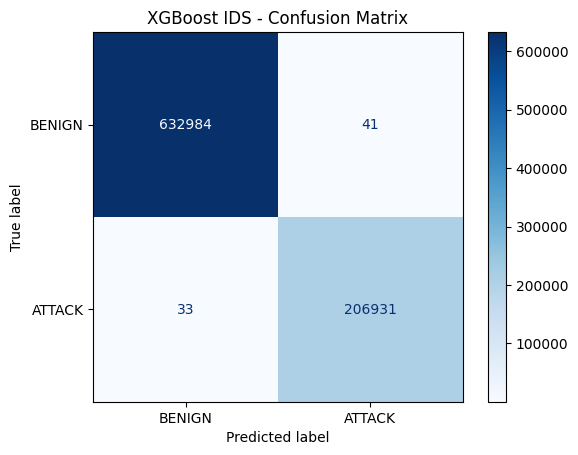


False Positives: 41
False Negatives: 33


In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN', 'ATTACK'])
disp.plot(cmap='Blues')
plt.title('XGBoost IDS - Confusion Matrix')
plt.savefig('../model/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# top right = false positives, bottom left = false negatives
print(f'\nFalse Positives: {cm[0][1]:,}')
print(f'False Negatives: {cm[1][0]:,}')